# FDSI benchmark: per-subject × per-condition hyperparameter optimisation then full adaptation

For each subject × condition combination one recording at `OPT_SNR = 30 dB` is used to
run Optuna CMA-ES (single-objective: `wh_loss + sv_loss`) and find the best combination
of `max_rel_delta_v`, `max_rel_delta_b`, `centroid_momentum`.  
The resulting per-(subject, condition) configs are then applied to all 100 FDSI recordings
(5 subjects × 5 conditions × 4 SNR levels).  
Evaluation follows the same RoA structure as `fdsi_01_apply_best_config.ipynb`.

**Fixed adaptation settings (shared)**
- `wh_mode = 'kl_to_cal'`
- `max_iter_b = 5`
- `wh_b_coupling = False`

**Optimised per subject × condition**
- `max_rel_delta_v`
- `max_rel_delta_b`
- `centroid_momentum`

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, DEFAULT_PARAM_SPACE
from adapt_decomp.utils import rate_of_agreement_paired

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

In [2]:
# ── Run control ───────────────────────────────────────────────────────────────
# WH_MODE          selects which set of results to use. Each mode has its own
#                  opt_configs/ and decomp_results/ subfolder, so results from
#                  different modes are never overwritten.
#                  Switch WH_MODE + set both flags to False to reload a previous run.
# RUN_OPTIMISATION = True  → run Optuna CMA-ES for every (subject, condition) pair.
#                  = False → load best-config JSONs from OPT_DIR.
# RUN_DECOMP       = True  → run adapt_decomp for all 100 recordings.
#                  = False → load cached spike arrays from DECOMP_DIR.
#                            opt_configs is always loaded from JSON so
#                            hyperparameters are available for analysis.
WH_MODE          = 'kl_to_cal'    # 'kl_to_cal' | 'kl_to_identity'
RUN_OPTIMISATION = False
RUN_DECOMP       = True

FDSI_ROOT   = Path('C:/Users/Irene/Documents/work_local/muniverse/outputs/fdsi_benchmark')
RESULTS_DIR = Path('..', 'data', 'fdsi_results', 'opt_per_cond')
OPT_DIR     = RESULTS_DIR / 'opt_configs'    / WH_MODE
DECOMP_DIR  = RESULTS_DIR / 'decomp_results' / WH_MODE
for d in [RESULTS_DIR, OPT_DIR, DECOMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
FS                = 2048
CAL_END           = int(5.0 * FS)   # 10240 — calibration window end (samples)
SUBJECTS          = [f'sub-{i:02d}' for i in range(1, 6)]
CONDITIONS        = ['triangular-ramp40s', 'triangular-ramp20s',
                     'triangular-ramp10s', 'triangular-ramp5s', 'staircase']
TRIANGULAR        = [c for c in CONDITIONS if 'triangular' in c]
SNR_LEVELS        = [30, 25, 20, 15]
ANGLE_ISO_THR_DEG = 2.0   # |angle| < threshold deg → isometric

# ── Optimisation settings ─────────────────────────────────────────────────────
OPT_SNR      = 30        # SNR level used for optimisation
OPT_N_TRIALS = 50        # Optuna CMA-ES trials per (subject, condition)

# ── Fixed adaptation settings shared across all optimisation runs ─────────────
BASE_CONFIG = {
    'ext_fact':          12,          # FDSI uses R=12
    'adapt_wh':          True,
    'adapt_sv':          True,
    'adapt_sd':          True,
    'wh_mode':           WH_MODE,
    'contrast_scope':    'spike_based',
    'extension_method':  'block',
    'wh_b_coupling':     False,
    'max_iter_b':        5,
    'log_loss':          True,
    'device':            'cpu',
    'trace_check':       True,
    'optim_loss':        'single_obj',
}

param_space  = DEFAULT_PARAM_SPACE
param_names  = list(param_space.keys())

print(f'FDSI root:     {FDSI_ROOT}')
print(f'Results dir:   {RESULTS_DIR}')
print(f'wh_mode:       {WH_MODE}')
print(f'OPT_DIR:       {OPT_DIR}')
print(f'DECOMP_DIR:    {DECOMP_DIR}')
print(f'Optimisation:  {"RUN" if RUN_OPTIMISATION else "LOAD from JSON"} '
      f'— all {len(SUBJECTS)} subjects × {len(CONDITIONS)} conditions at SNR={OPT_SNR} dB')
print(f'Decomposition: {"RUN" if RUN_DECOMP else "LOAD from cache"}')
print(f'Recordings to evaluate: {len(SUBJECTS)} subs × {len(CONDITIONS)} conds × '
      f'{len(SNR_LEVELS)} SNR = {len(SUBJECTS)*len(CONDITIONS)*len(SNR_LEVELS)}')

FDSI root:     C:\Users\Irene\Documents\work_local\muniverse\outputs\fdsi_benchmark
Results dir:   ..\data\fdsi_results\opt_per_cond
wh_mode:       kl_to_cal
OPT_DIR:       ..\data\fdsi_results\opt_per_cond\opt_configs\kl_to_cal
DECOMP_DIR:    ..\data\fdsi_results\opt_per_cond\decomp_results\kl_to_cal
Optimisation:  LOAD from JSON — all 5 subjects × 5 conditions at SNR=30 dB
Decomposition: RUN
Recordings to evaluate: 5 subs × 5 conds × 4 SNR = 100


## 1. Helper functions

In [3]:
def load_fdsi_recording(root, sub, cond, snr):
    """Load one FDSI recording into tensors shaped for AdaptDecomp.

    Returns a dict with all calibration tensors, the adaptation EMG,
    biomechanical signals, and ground-truth spike trains.
    """
    root = Path(root)

    # ── Calibration package ───────────────────────────────────────────────────
    cal_path = (root / 'calibrated_units_block' / sub
                / f'{sub}_FDSI_{cond}_snr{snr}dB_calibrated_units.npz')
    cal = np.load(cal_path)

    n_hq         = cal['mu_filters'].shape[1]
    est_unit_ids = cal['est_unit_ids']

    whitening       = torch.from_numpy(cal['whitening'].astype(np.float32))          # (1200,1200)
    sep_vectors     = torch.from_numpy(cal['mu_filters'].T.astype(np.float32))       # (n_hq,1200)
    base_centroids  = torch.from_numpy(cal['centroids'][:, 0].astype(np.float32))   # (n_hq,)
    spike_centroids = torch.from_numpy(cal['centroids'][:, 1].astype(np.float32))   # (n_hq,)
    emg_calib       = torch.from_numpy(cal['emg_cal'].T.astype(np.float32))          # (10240,100)
    ipts_calib      = torch.from_numpy(cal['sources'].T.astype(np.float32))          # (10240,n_hq)

    spikes_cal_np = np.zeros((CAL_END, n_hq), dtype=np.float32)
    for i, uid in enumerate(est_unit_ids):
        key = f'spikes_unit{uid}'
        if key in cal:
            idx = cal[key].astype(int)
            idx = idx[(idx >= 0) & (idx < CAL_END)]
            spikes_cal_np[idx, i] = 1.0
    spikes_calib = torch.from_numpy(spikes_cal_np)

    gt_unit_labels = cal['gt_unit_labels']

    # ── Noisy EMG (adaptation segment) ───────────────────────────────────────
    emg_path  = root / 'data' / sub / 'noisy' / f'{sub}_FDSI_{cond}_snr{snr}dB_emg.npz'
    emg_full  = np.load(emg_path)['emg']                                 # (n_samples,100)
    emg_adapt = torch.from_numpy(emg_full[CAL_END:].astype(np.float32))  # (n_adapt,100)

    # ── Biomechanical signals (adaptation segment) ────────────────────────────
    clean_dir    = root / 'data' / sub / 'clean'
    angle_adapt  = np.load(clean_dir / f'{sub}_FDSI_{cond}_angle.npz')['angle'][CAL_END:]
    effort_adapt = np.load(clean_dir / f'{sub}_FDSI_{cond}_effort.npz')['effort'][CAL_END:]

    # ── Ground-truth spike trains ─────────────────────────────────────────────
    spikes_obj = np.load(
        clean_dir / f'{sub}_FDSI_{cond}_spikes.npz', allow_pickle=True
    )['spikes']

    return {
        'whitening':       whitening,
        'sep_vectors':     sep_vectors,
        'base_centroids':  base_centroids,
        'spike_centroids': spike_centroids,
        'emg_calib':       emg_calib,
        'ipts_calib':      ipts_calib,
        'spikes_calib':    spikes_calib,
        'emg_adapt':       emg_adapt,
        'angle_adapt':     angle_adapt,
        'effort_adapt':    effort_adapt,
        'spikes_obj':      spikes_obj,
        'gt_unit_labels':  gt_unit_labels,
        'n_hq':            n_hq,
    }

In [4]:
def build_gt_binary(spikes_obj, gt_unit_labels, n_adapt):
    """Convert GT spike object array to a binary matrix (n_adapt, n_hq)."""
    n_hq   = len(gt_unit_labels)
    gt_bin = np.zeros((n_adapt, n_hq), dtype=np.float32)
    for i, gt_idx in enumerate(gt_unit_labels):
        gt_samples    = np.asarray(spikes_obj[gt_idx])
        adapt_samples = gt_samples[gt_samples >= CAL_END] - CAL_END
        adapt_samples = adapt_samples[adapt_samples < n_adapt].astype(int)
        gt_bin[adapt_samples, i] = 1.0
    return gt_bin


def _to_json_safe(v):
    if isinstance(v, torch.Tensor): return v.item()
    if hasattr(v, 'item'): return v.item()
    return v

In [5]:
def detect_triangular_phases(angle_adapt):
    """Split adaptation segment into first isometric / ramp / last isometric."""
    n      = len(angle_adapt)
    is_iso = np.abs(angle_adapt) < ANGLE_ISO_THR_DEG
    idx    = np.arange(n)

    ramp_start = int(np.argmax(~is_iso))
    ramp_end   = n - 1 - int(np.argmax(~is_iso[::-1]))

    first_iso = idx[(idx < ramp_start) & is_iso]
    ramp      = np.arange(ramp_start, ramp_end + 1)
    last_iso  = idx[(idx > ramp_end) & is_iso]

    return {
        'first_iso':  first_iso,
        'ramp':       ramp,
        'last_iso':   last_iso,
        'ramp_start': ramp_start,
        'ramp_end':   ramp_end,
    }


def compute_roa_subset(gt_bin, pred_spikes, idx):
    """RoA for a temporal subset; NaN if the subset is empty."""
    if len(idx) == 0:
        return np.full(gt_bin.shape[1], np.nan)
    roa, _, _ = rate_of_agreement_paired(
        gt_bin[idx], pred_spikes[idx], fs=FS, tol_spike_ms=2
    )
    return roa

## 2. Per-subject × per-condition hyperparameter optimisation

One recording per (subject, condition) at `OPT_SNR = 30 dB` is passed to
Optuna CMA-ES (`n_trials = 50`).  The objective is `wh_loss + sv_loss` (single-objective).
Searched parameters: `max_rel_delta_v`, `max_rel_delta_b`, `centroid_momentum`.

Configs are saved to `OPT_DIR / {sub}_{cond}_best_config.json` and reloaded when
`RUN_OPTIMISATION = False`.

In [6]:
opt_configs = {}  # keyed by (subject, condition)

for sub in tqdm(SUBJECTS, desc='subject'):
    for cond in tqdm(CONDITIONS, desc='condition', leave=False):
        cfg_path = OPT_DIR / f'{sub}_{cond}_best_config.json'

        if not RUN_OPTIMISATION and cfg_path.exists():
            with open(cfg_path) as f:
                opt_configs[(sub, cond)] = json.load(f)
        else:
            data = load_fdsi_recording(FDSI_ROOT, sub, cond, OPT_SNR)

            best_cfg, _ = optimize_adapt_decomp(
                emg             = data['emg_adapt'],
                whitening       = data['whitening'],
                sep_vectors     = data['sep_vectors'],
                base_centroids  = data['base_centroids'],
                spike_centroids = data['spike_centroids'],
                emg_calib       = data['emg_calib'],
                ipts_calib      = data['ipts_calib'],
                spikes_calib    = data['spikes_calib'],
                param_space     = param_space,
                base_config     = BASE_CONFIG,
                n_trials        = OPT_N_TRIALS,
                preprocess      = False,
            )
            with open(cfg_path, 'w') as f:
                json.dump({k: _to_json_safe(v) for k, v in best_cfg.items()}, f, indent=2)
            opt_configs[(sub, cond)] = best_cfg

action = 'Optimised' if RUN_OPTIMISATION else 'Loaded'
print(f'{action} {len(opt_configs)} configs ({len(SUBJECTS)} subjects × {len(CONDITIONS)} conditions).')

subject:   0%|          | 0/5 [00:00<?, ?it/s]

condition:   0%|          | 0/5 [00:00<?, ?it/s]

condition:   0%|          | 0/5 [00:00<?, ?it/s]

condition:   0%|          | 0/5 [00:00<?, ?it/s]

condition:   0%|          | 0/5 [00:00<?, ?it/s]

condition:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded 25 configs (5 subjects × 5 conditions).


### 2a. Hyperparameter inspection — per-subject × per-condition heatmaps

One heatmap per optimised parameter (rows = subjects, columns = conditions).
Uniform colour across subjects or conditions indicates that the parameter
is not particularly subject- or condition-specific.

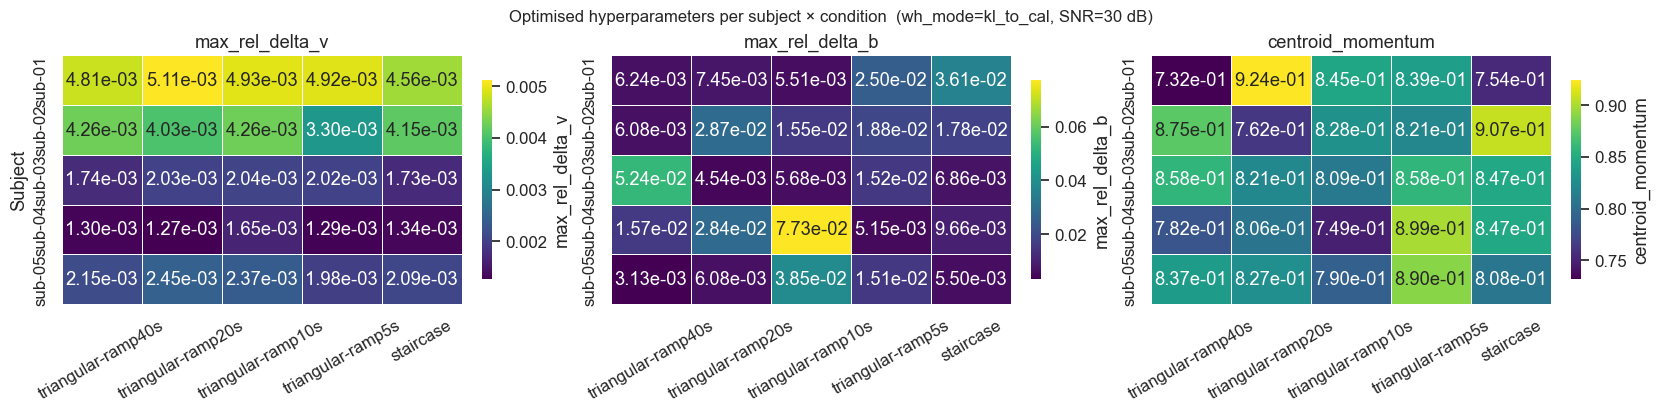


Optimised hyperparameter values  (wh_mode=kl_to_cal, SNR=30 dB):

── max_rel_delta_v ──
condition  triangular-ramp40s  triangular-ramp20s  triangular-ramp10s  triangular-ramp5s  staircase
subject                                                                                            
sub-01             4.8087e-03          5.1137e-03          4.9336e-03         4.9232e-03 4.5598e-03
sub-02             4.2597e-03          4.0320e-03          4.2641e-03         3.2972e-03 4.1541e-03
sub-03             1.7384e-03          2.0295e-03          2.0354e-03         2.0224e-03 1.7293e-03
sub-04             1.3036e-03          1.2683e-03          1.6517e-03         1.2876e-03 1.3368e-03
sub-05             2.1531e-03          2.4490e-03          2.3697e-03         1.9771e-03 2.0864e-03
  CV across subjects (per condition): triangular-ramp40s: 0.55  triangular-ramp20s: 0.52  triangular-ramp10s: 0.48  triangular-ramp5s: 0.53  staircase: 0.53
  CV across conditions (per subject): sub-01: 0.04  su

In [7]:
# ── Build long-form DataFrame of optimised hyperparameters ────────────────────
df_params = pd.DataFrame([
    {'subject': sub, 'condition': cond, **{p: cfg[p] for p in param_names}}
    for (sub, cond), cfg in opt_configs.items()
])

# ── Heatmaps: one subplot per parameter ──────────────────────────────────────
n_params = len(param_names)
fig, axs = plt.subplots(1, n_params, figsize=(5.5 * n_params, 4), layout='constrained')

for i, (ax, param) in enumerate(zip(axs, param_names)):
    pivot = (df_params
             .pivot(index='subject', columns='condition', values=param)
             .reindex(index=SUBJECTS, columns=CONDITIONS))
    annot = pivot.map(lambda x: f'{x:.2e}')
    sns.heatmap(
        pivot, annot=annot, fmt='s', ax=ax,
        cmap='viridis', linewidths=0.5, linecolor='white',
        cbar_kws={'label': param, 'shrink': 0.8},
    )
    ax.set(title=param, xlabel='')
    ax.set_ylabel('Subject' if i == 0 else '')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    f'Optimised hyperparameters per subject × condition'
    f'  (wh_mode={WH_MODE}, SNR={OPT_SNR} dB)',
    fontsize=12,
)
plt.show()

# ── Numeric tables ────────────────────────────────────────────────────────────
print(f'\nOptimised hyperparameter values  (wh_mode={WH_MODE}, SNR={OPT_SNR} dB):\n')
for param in param_names:
    pivot = (df_params
             .pivot(index='subject', columns='condition', values=param)
             .reindex(index=SUBJECTS, columns=CONDITIONS))
    print(f'── {param} ──')
    print(pivot.to_string(float_format=lambda x: f'{x:.4e}'))

    col_cv = pivot.std() / pivot.mean()
    row_cv = pivot.std(axis=1) / pivot.mean(axis=1)
    print(f'  CV across subjects (per condition): '
          + '  '.join(f'{c}: {v:.2f}' for c, v in col_cv.items()))
    print(f'  CV across conditions (per subject): '
          + '  '.join(f'{s}: {v:.2f}' for s, v in row_cv.items()))
    print()

## 3. Run adapt_decomp with per-subject × per-condition optimised configs

For each `(subject, condition, SNR)` triplet the config optimised for that
(subject, condition) pair at `OPT_SNR = 30 dB` is applied.
Results are cached as `.npz` files so the notebook can be re-run with `RUN_DECOMP = False`.

In [8]:
# ── Ensure opt_configs is available (loads from disk if section 2 was not run) ─
if 'opt_configs' not in vars() or not opt_configs:
    opt_configs = {}
    for sub in SUBJECTS:
        for cond in CONDITIONS:
            cfg_path = OPT_DIR / f'{sub}_{cond}_best_config.json'
            if not cfg_path.exists():
                raise FileNotFoundError(
                    f'No saved config for {sub}/{cond}. Run Section 2 first.')
            with open(cfg_path) as f:
                opt_configs[(sub, cond)] = json.load(f)
    print(f'opt_configs loaded from disk ({len(opt_configs)} entries).')

# ── Run or reload decomposition ───────────────────────────────────────────────
results = {}

pbar = tqdm(
    total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS),
    desc='adapt_decomp',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        cfg_this = opt_configs[(sub, cond)]
        for snr in SNR_LEVELS:
            key       = (sub, cond, snr)
            cache_dir = DECOMP_DIR / sub / cond
            cache_dir.mkdir(parents=True, exist_ok=True)
            path_opt   = cache_dir / f'snr{snr}dB_spikes.npz'
            path_noopt = cache_dir / f'snr{snr}dB_noopt_spikes.npz'

            data    = load_fdsi_recording(FDSI_ROOT, sub, cond, snr)
            n_adapt = len(data['angle_adapt'])
            gt_bin  = build_gt_binary(data['spikes_obj'], data['gt_unit_labels'], n_adapt)

            def _build_dec(cfg_dict, data_dict, adapt: bool):
                cfg = Config()
                for k, v in cfg_dict.items():
                    setattr(cfg, k, v)
                if not adapt:
                    cfg.adapt_wh = False
                    cfg.adapt_sv = False
                    cfg.adapt_sd = False
                return AdaptDecomp(
                    emg             = data_dict['emg_adapt'].clone(),
                    whitening       = data_dict['whitening'].clone(),
                    sep_vectors     = data_dict['sep_vectors'].clone(),
                    base_centroids  = data_dict['base_centroids'].clone(),
                    spike_centroids = data_dict['spike_centroids'].clone(),
                    emg_calib       = data_dict['emg_calib'].clone(),
                    ipts_calib      = data_dict['ipts_calib'].clone(),
                    spikes_calib    = data_dict['spikes_calib'].clone(),
                    preprocess      = False,
                    config          = cfg,
                )

            # ── Adapted run ────────────────────────────────────────────────
            if not RUN_DECOMP and path_opt.exists():
                c       = np.load(path_opt)
                spikes  = c['spikes']
                wh_loss = c['wh_loss'] if 'wh_loss' in c.files else np.array([])
                sv_loss = c['sv_loss'] if 'sv_loss' in c.files else np.array([])
            else:
                out     = _build_dec(cfg_this, data, adapt=True).run()
                spikes  = out['spikes'].numpy()
                wh_loss = out['wh_loss'].numpy()
                sv_loss = out['sv_loss'].numpy()
                np.savez_compressed(path_opt, spikes=spikes,
                                    wh_loss=wh_loss, sv_loss=sv_loss)

            # ── No-adaptation baseline ─────────────────────────────────────
            if not RUN_DECOMP and path_noopt.exists():
                c             = np.load(path_noopt)
                spikes_noopt  = c['spikes']
                wh_loss_noopt = c['wh_loss'] if 'wh_loss' in c.files else np.array([])
                sv_loss_noopt = c['sv_loss'] if 'sv_loss' in c.files else np.array([])
            else:
                out_no        = _build_dec(cfg_this, data, adapt=False).run()
                spikes_noopt  = out_no['spikes'].numpy()
                wh_loss_noopt = out_no['wh_loss'].numpy()
                sv_loss_noopt = out_no['sv_loss'].numpy()
                np.savez_compressed(path_noopt, spikes=spikes_noopt,
                                    wh_loss=wh_loss_noopt, sv_loss=sv_loss_noopt)

            results[key] = {
                'spikes':        spikes,
                'spikes_noopt':  spikes_noopt,
                'gt_bin':        gt_bin,
                'angle_adapt':   data['angle_adapt'],
                'n_hq':          data['n_hq'],
                'wh_loss':       wh_loss,
                'sv_loss':       sv_loss,
                'wh_loss_noopt': wh_loss_noopt,
                'sv_loss_noopt': sv_loss_noopt,
            }
            pbar.update(1)

pbar.close()
print(f'Done. {len(results)} recordings processed.')

adapt_decomp:   0%|          | 0/100 [00:00<?, ?it/s]

Done. 100 recordings processed.


## 3a. Adaptation losses — adapted vs no-adaptation

`wh_loss` measures how far the whitening matrix drifts from its calibration value.
`sv_loss` measures how far the source-vector inner products drift from independence.
Both are the quantities the optimiser minimises; comparing them with and without adaptation
reveals whether the online update is actually driving the loss down.

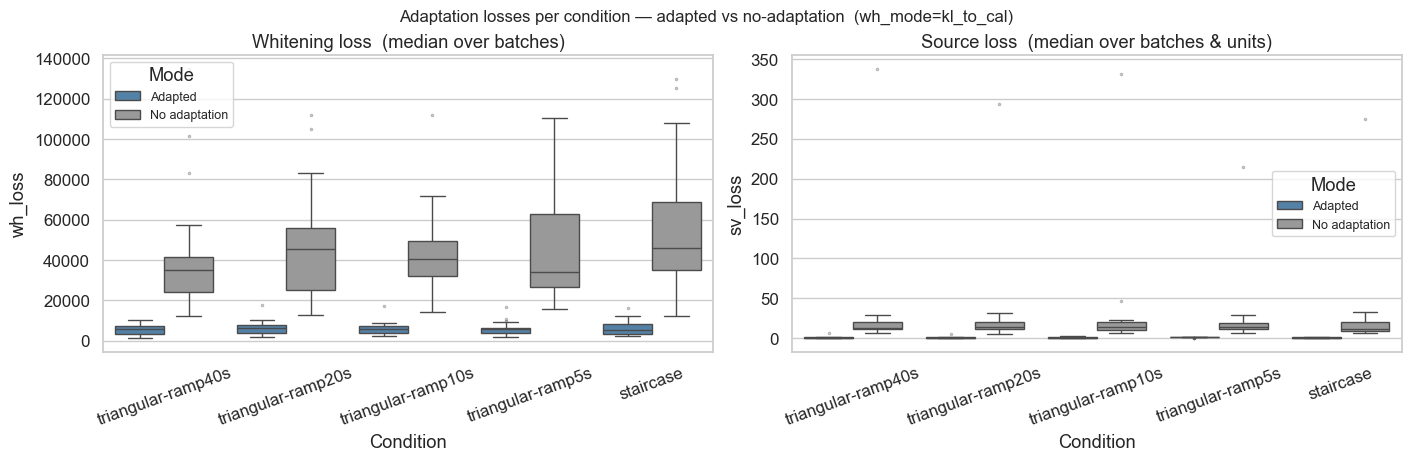

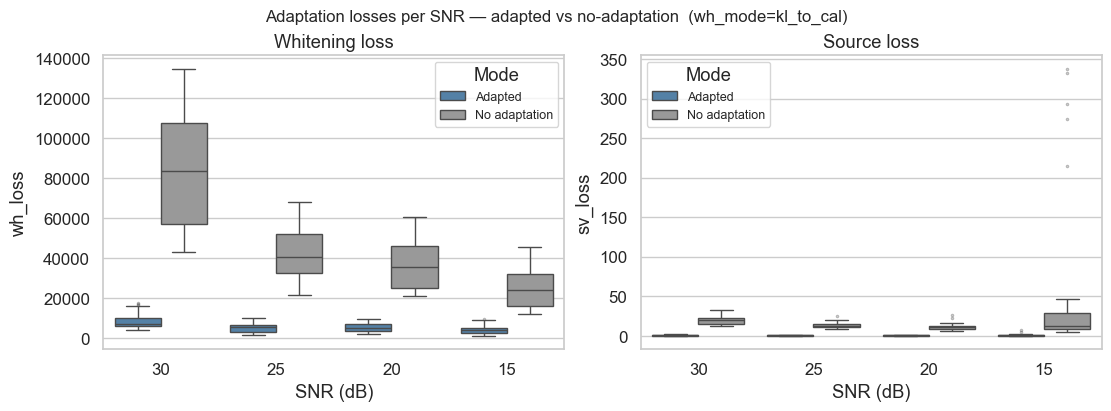

Median losses averaged per condition:
                                     wh_loss  sv_loss
condition          mode                              
staircase          Adapted         6015.5450   0.7418
                   No adaptation  57380.1372  27.2409
triangular-ramp10s Adapted         5861.2067   0.8870
                   No adaptation  42785.9976  31.0787
triangular-ramp20s Adapted         6406.5241   0.8268
                   No adaptation  47486.4228  30.1052
triangular-ramp40s Adapted         5602.9132   0.8749
                   No adaptation  43105.0834  30.9769
triangular-ramp5s  Adapted         6185.9122   1.2096
                   No adaptation  45100.4567  25.1730


In [9]:
# ── Build per-recording loss summary DataFrame ────────────────────────────────
loss_rows = []
for (sub, cond, snr), res in results.items():
    for mode, wl, sl in [
        ('Adapted',       res.get('wh_loss'),       res.get('sv_loss')),
        ('No adaptation', res.get('wh_loss_noopt'), res.get('sv_loss_noopt')),
    ]:
        if wl is not None and len(wl) > 0:
            loss_rows.append({
                'sub': sub, 'condition': cond, 'snr': snr,
                'mode':    mode,
                'wh_loss': float(np.nanmedian(wl)),
                'sv_loss': float(np.nanmedian(sl)),
            })

df_loss = pd.DataFrame(loss_rows)

if df_loss.empty:
    print('No loss data — set RUN_DECOMP=True and re-run section 3 to compute losses.')
else:
    hue_order = ['Adapted', 'No adaptation']
    palette   = {'Adapted': 'steelblue', 'No adaptation': '#999999'}

    # ── Loss per condition ────────────────────────────────────────────────────
    fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), layout='constrained')
    for ax, metric, label in [
        (axs[0], 'wh_loss', 'Whitening loss  (median over batches)'),
        (axs[1], 'sv_loss', 'Source loss  (median over batches & units)'),
    ]:
        sns.boxplot(
            data=df_loss, x='condition', y=metric, hue='mode',
            order=CONDITIONS, hue_order=hue_order,
            palette=palette, ax=ax,
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
        )
        ax.set(title=label, xlabel='Condition', ylabel=metric)
        ax.tick_params(axis='x', rotation=20)
        ax.legend(title='Mode', fontsize=9)
    plt.suptitle(
        f'Adaptation losses per condition — adapted vs no-adaptation  (wh_mode={WH_MODE})',
        fontsize=12,
    )
    plt.show()

    # ── Loss per SNR level ────────────────────────────────────────────────────
    fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='constrained')
    for ax, metric, label in [
        (axs[0], 'wh_loss', 'Whitening loss'),
        (axs[1], 'sv_loss', 'Source loss'),
    ]:
        sns.boxplot(
            data=df_loss, x='snr', y=metric, hue='mode',
            order=SNR_LEVELS, hue_order=hue_order,
            palette=palette, ax=ax,
            flierprops=dict(marker='.', markersize=3, alpha=0.4),
        )
        ax.set(title=label, xlabel='SNR (dB)', ylabel=metric)
        ax.legend(title='Mode', fontsize=9)
    plt.suptitle(
        f'Adaptation losses per SNR — adapted vs no-adaptation  (wh_mode={WH_MODE})',
        fontsize=12,
    )
    plt.show()

    # ── Numeric summary ───────────────────────────────────────────────────────
    print('Median losses averaged per condition:')
    print(
        df_loss.groupby(['condition', 'mode'])[['wh_loss', 'sv_loss']]
        .mean().round(4).to_string()
    )

### 3b. Loss time-courses — adapted vs no-adaptation

Per-batch `wh_loss` and `sv_loss` trajectories (mean ± std across subjects).
- **If losses are lower for adapted than no-adapt** → the proxy objective is being minimised,
  but it does not correlate with RoA (objective mismatch).
- **If losses are NOT lower for adapted** → the online updates are not even achieving the
  proxy objective; look for instability or wrong-direction gradients.

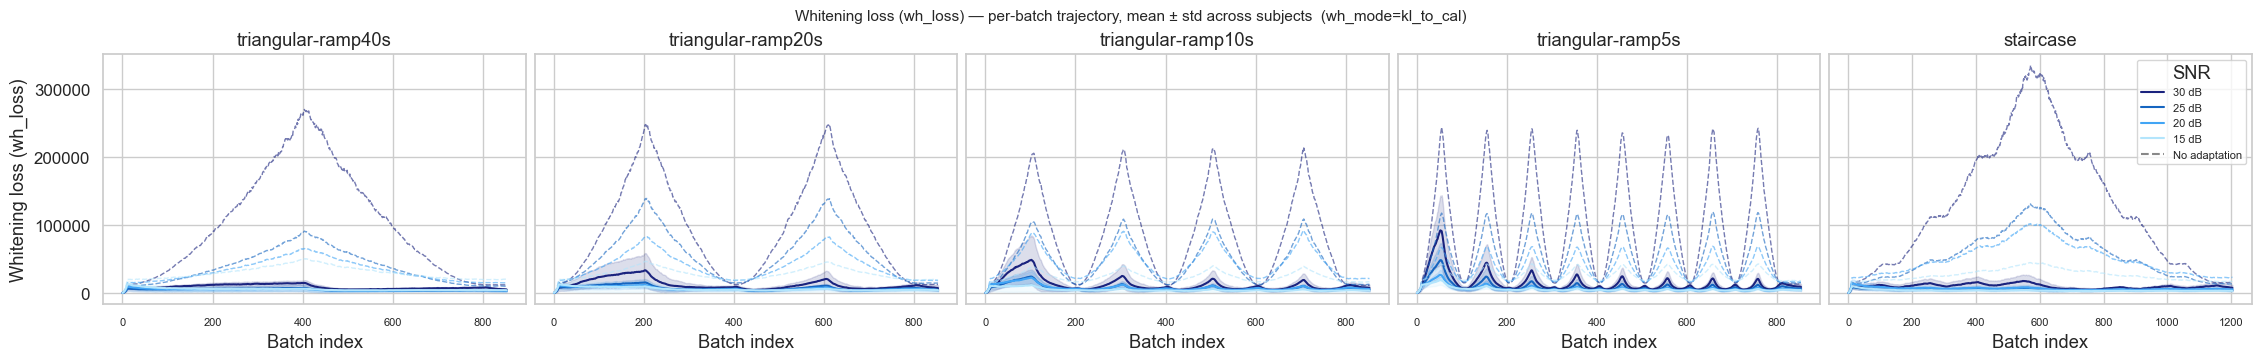

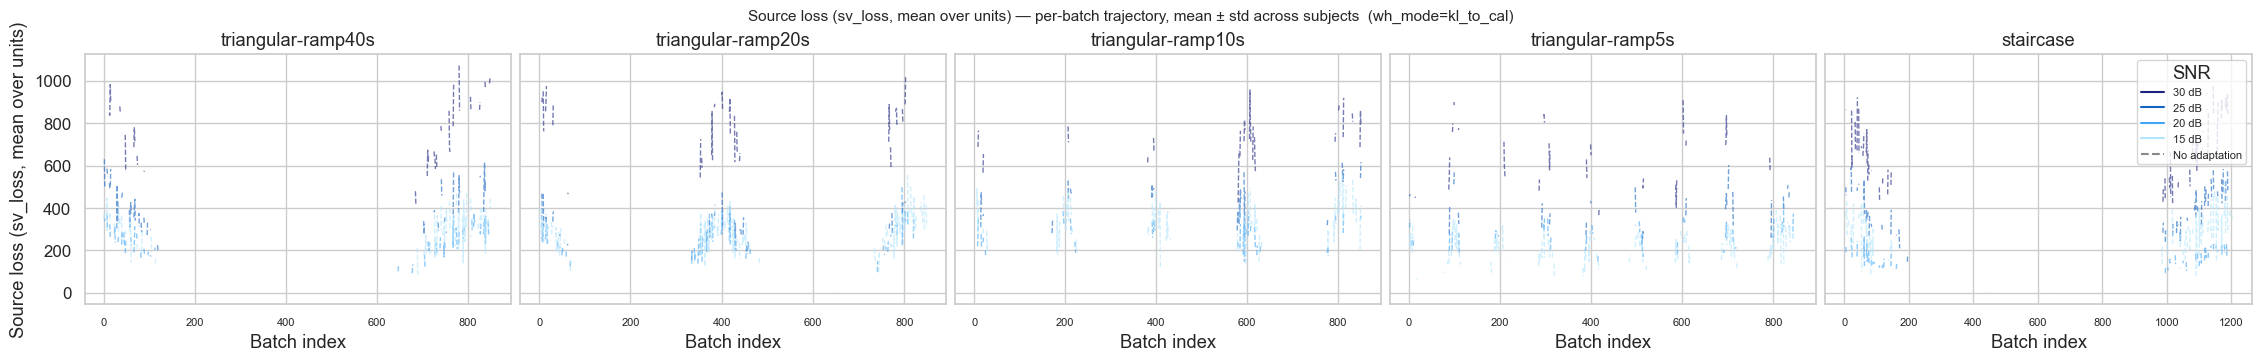

In [19]:
# ── Build per-batch loss trajectories: mean ± std across subjects ─────────────
# wh_loss: [batches]     sv_loss: [batches, M] → take mean over M first
batch_losses = {}
for cond in CONDITIONS:
    for snr in SNR_LEVELS:
        ad_wh, no_wh, ad_sv, no_sv = [], [], [], []
        for sub in SUBJECTS:
            res = results.get((sub, cond, snr), {})
            wl  = res.get('wh_loss',       np.array([]))
            wln = res.get('wh_loss_noopt', np.array([]))
            sl  = res.get('sv_loss',       np.array([]))
            sln = res.get('sv_loss_noopt', np.array([]))
            if len(wl) == 0:
                continue
            ad_wh.append(wl)
            no_wh.append(wln)
            ad_sv.append(sl.mean(axis=1) if sl.ndim == 2 else sl)
            no_sv.append(sln.mean(axis=1) if sln.ndim == 2 else sln)

        if not ad_wh:
            continue
        n = min(len(x) for x in ad_wh + no_wh)
        batch_losses[(cond, snr)] = {
            'ad_wh': np.array([x[:n] for x in ad_wh]),  # (n_subs, n_batches)
            'no_wh': np.array([x[:n] for x in no_wh]),
            'ad_sv': np.array([x[:n] for x in ad_sv]),
            'no_sv': np.array([x[:n] for x in no_sv]),
        }

if not batch_losses:
    print('No per-batch loss data — set RUN_DECOMP=True and re-run section 3.')
else:
    _colors = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

    for loss_key, loss_label in [('wh', 'Whitening loss (wh_loss)'),
                                  ('sv', 'Source loss (sv_loss, mean over units)')]:
        fig, axs = plt.subplots(1, len(CONDITIONS), figsize=(4.5 * len(CONDITIONS), 3.5),
                                layout='constrained', sharey=True)

        for ax, cond in zip(axs, CONDITIONS):
            for snr in SNR_LEVELS:
                key = (cond, snr)
                if key not in batch_losses:
                    continue
                bl  = batch_losses[key]
                arr_ad = bl[f'ad_{loss_key}']   # (n_subs, batches)
                arr_no = bl[f'no_{loss_key}']
                x      = np.arange(arr_ad.shape[1])
                c      = _colors[snr]

                m_ad, s_ad = arr_ad.mean(0), arr_ad.std(0)
                m_no, s_no = arr_no.mean(0), arr_no.std(0)

                ax.plot(x, m_ad, color=c, linewidth=1.5, label=f'{snr} dB')
                ax.fill_between(x, m_ad - s_ad, m_ad + s_ad, color=c, alpha=0.15)
                ax.plot(x, m_no, color=c, linewidth=1.0, linestyle='--', alpha=0.6)

            ax.set(title=cond, xlabel='Batch index')
            ax.tick_params(axis='x', labelsize=8)
            if ax is axs[0]:
                ax.set_ylabel(loss_label)

        # Legend: SNR (solid) + no-adapt indicator (dashed)
        handles_s, labels_s = axs[0].get_legend_handles_labels()
        import matplotlib.lines as mlines
        dash_h = mlines.Line2D([], [], color='#888', linewidth=1.5, linestyle='--',
                               label='No adaptation')
        axs[-1].legend(handles=handles_s + [dash_h],
                       labels=labels_s + ['No adaptation'],
                       fontsize=8, loc='upper right', title='SNR')

        plt.suptitle(
            f'{loss_label} — per-batch trajectory, mean ± std across subjects'
            f'  (wh_mode={WH_MODE})',
            fontsize=11,
        )
        plt.show()

### 3c. Spike detection rate per batch

If `sv_loss ≈ 0` because barely any spikes are detected, the adapted spike rate (solid)
will be visibly lower than no-adapt (dashed). A drop that starts *immediately* points to
centroid drift (threshold wrong from the first batch); a progressive collapse points to
sep-vector corruption accumulating over time.

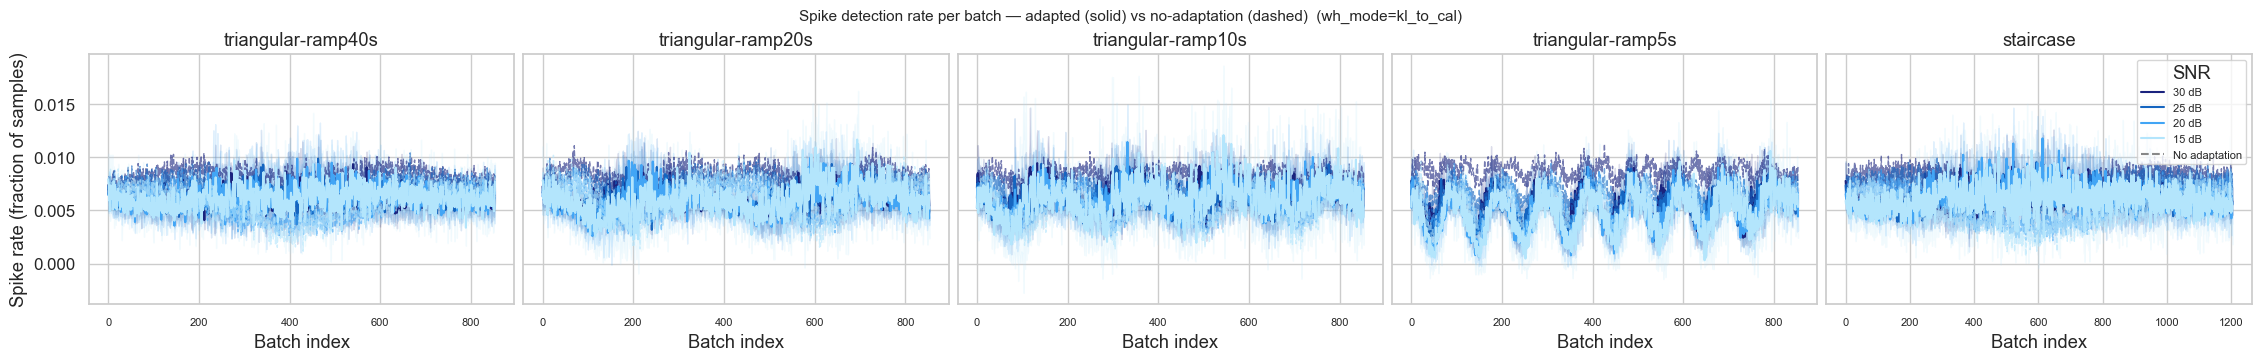

In [20]:
# ── Spike detection rate per batch (fraction of (sample × unit) pairs = 1) ────
spike_rate_data = {}
for cond in CONDITIONS:
    for snr in SNR_LEVELS:
        rates_ad, rates_no = [], []
        for sub in SUBJECTS:
            res = results.get((sub, cond, snr), {})
            spk    = res.get('spikes')
            spk_no = res.get('spikes_noopt')
            wl     = res.get('wh_loss', np.array([]))
            if spk is None or len(wl) == 0:
                continue
            n_batches = len(wl)
            bs        = spk.shape[0] // n_batches
            if bs == 0:
                continue
            rates_ad.append(np.array([spk[b*bs:(b+1)*bs].mean()    for b in range(n_batches)]))
            rates_no.append(np.array([spk_no[b*bs:(b+1)*bs].mean() for b in range(n_batches)]))

        if not rates_ad:
            continue
        n = min(len(x) for x in rates_ad + rates_no)
        spike_rate_data[(cond, snr)] = {
            'ad': np.array([x[:n] for x in rates_ad]),
            'no': np.array([x[:n] for x in rates_no]),
        }

if not spike_rate_data:
    print('No data — re-run section 3 with RUN_DECOMP=True.')
else:
    _colors = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

    fig, axs = plt.subplots(1, len(CONDITIONS), figsize=(4.5 * len(CONDITIONS), 3.5),
                            layout='constrained', sharey=True)

    for ax, cond in zip(axs, CONDITIONS):
        for snr in SNR_LEVELS:
            key = (cond, snr)
            if key not in spike_rate_data:
                continue
            d   = spike_rate_data[key]
            x   = np.arange(d['ad'].shape[1])
            c   = _colors[snr]
            m_ad, s_ad = d['ad'].mean(0), d['ad'].std(0)
            m_no, s_no = d['no'].mean(0), d['no'].std(0)

            ax.plot(x, m_ad, color=c, linewidth=1.5, label=f'{snr} dB')
            ax.fill_between(x, m_ad - s_ad, m_ad + s_ad, color=c, alpha=0.15)
            ax.plot(x, m_no, color=c, linewidth=1.0, linestyle='--', alpha=0.6)

        ax.set(title=cond, xlabel='Batch index')
        ax.tick_params(axis='x', labelsize=8)
        if ax is axs[0]:
            ax.set_ylabel('Spike rate (fraction of samples)')

    import matplotlib.lines as mlines
    handles_s, labels_s = axs[0].get_legend_handles_labels()
    dash_h = mlines.Line2D([], [], color='#888', linewidth=1.5, linestyle='--',
                           label='No adaptation')
    axs[-1].legend(handles=handles_s + [dash_h], labels=labels_s + ['No adaptation'],
                   fontsize=8, title='SNR', loc='upper right')

    plt.suptitle(
        f'Spike detection rate per batch — adapted (solid) vs no-adaptation (dashed)'
        f'  (wh_mode={WH_MODE})',
        fontsize=11,
    )
    plt.show()

### 3d. Component ablation — which adaptation flag kills spike detection?

Runs five configurations on a single reference recording using the optimised config for
that (subject, condition): no adaptation, each component enabled alone, and all three
together. Comparing spike rate and RoA across these directly isolates whether the failure
is driven by `adapt_wh`, `adapt_sv`, or `adapt_sd`.

ablation:   0%|          | 0/6 [00:00<?, ?it/s]

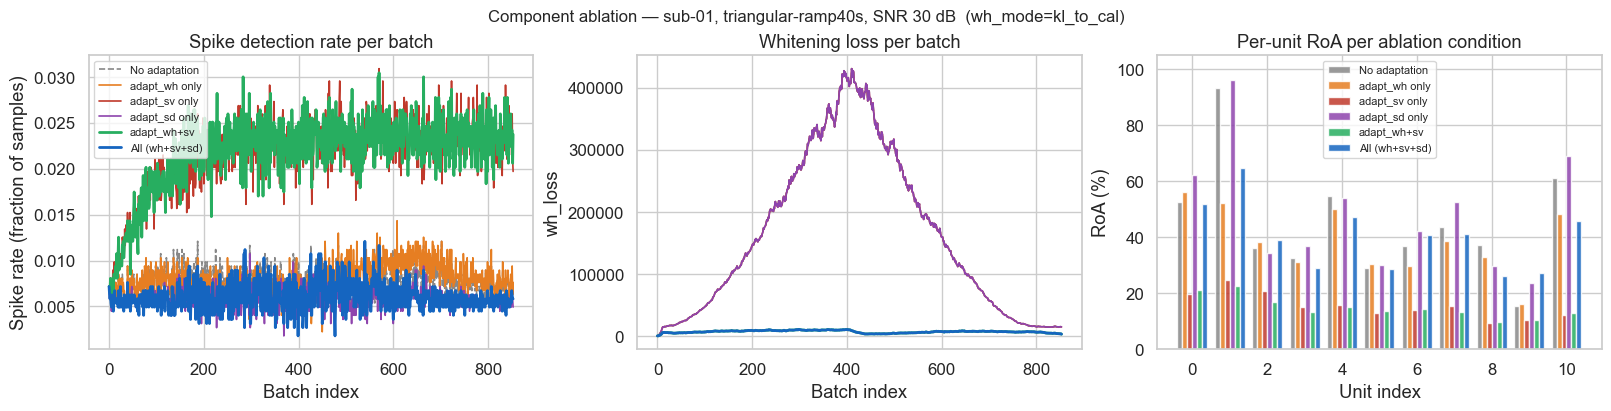

Mean RoA (%) per ablation condition:
  No adaptation           mean=44.8%  spike_rate=0.762%  wh_loss=162859.7656
  adapt_wh only           mean=38.5%  spike_rate=0.799%  wh_loss=6854.2891
  adapt_sv only           mean=15.5%  spike_rate=2.162%  wh_loss=162859.7656
  adapt_sd only           mean=48.3%  spike_rate=0.589%  wh_loss=162859.7656
  adapt_wh+sv             mean=14.9%  spike_rate=2.190%  wh_loss=6854.2891
  All (wh+sv+sd)          mean=40.2%  spike_rate=0.605%  wh_loss=6854.2891


In [23]:
# ── Reference recording to ablate (change these to explore different subjects) ─
ABL_SUB  = 'sub-01'
ABL_COND = 'triangular-ramp40s'
ABL_SNR  = 30

ABLATION_CONFIGS = {
    'No adaptation':   dict(adapt_wh=False, adapt_sv=False, adapt_sd=False),
    'adapt_wh only':   dict(adapt_wh=True,  adapt_sv=False, adapt_sd=False),
    'adapt_sv only':   dict(adapt_wh=False, adapt_sv=True,  adapt_sd=False),
    'adapt_sd only':   dict(adapt_wh=False, adapt_sv=False, adapt_sd=True),
    'adapt_wh+sv':     dict(adapt_wh=True,  adapt_sv=True,  adapt_sd=False),
    'All (wh+sv+sd)':  dict(adapt_wh=True,  adapt_sv=True,  adapt_sd=True),
}
ABL_COLORS = {
    'No adaptation':   '#888888',
    'adapt_wh only':   '#e67e22',
    'adapt_sv only':   '#c0392b',
    'adapt_sd only':   '#8e44ad',
    'adapt_wh+sv':     '#27ae60',
    'All (wh+sv+sd)':  '#1565c0',
}

# ── Load reference recording ───────────────────────────────────────────────────
_data    = load_fdsi_recording(FDSI_ROOT, ABL_SUB, ABL_COND, ABL_SNR)
_n       = len(_data['angle_adapt'])
_gt_bin  = build_gt_binary(_data['spikes_obj'], _data['gt_unit_labels'], _n)
_cfg_ref = opt_configs[(ABL_SUB, ABL_COND)]

# ── Run each ablation configuration ───────────────────────────────────────────
abl = {}
for label, overrides in tqdm(ABLATION_CONFIGS.items(), desc='ablation'):
    cfg = Config()
    for k, v in _cfg_ref.items():
        setattr(cfg, k, v)
    for k, v in overrides.items():
        setattr(cfg, k, v)

    out = AdaptDecomp(
        emg             = _data['emg_adapt'].clone(),
        whitening       = _data['whitening'].clone(),
        sep_vectors     = _data['sep_vectors'].clone(),
        base_centroids  = _data['base_centroids'].clone(),
        spike_centroids = _data['spike_centroids'].clone(),
        emg_calib       = _data['emg_calib'].clone(),
        ipts_calib      = _data['ipts_calib'].clone(),
        spikes_calib    = _data['spikes_calib'].clone(),
        preprocess      = False,
        config          = cfg,
    ).run()

    spk       = out['spikes'].numpy()
    wl        = out['wh_loss'].numpy()
    sl        = out['sv_loss'].numpy()
    n_batches = len(wl)
    bs        = _n // n_batches if n_batches > 0 else _n
    roa, _, _ = rate_of_agreement_paired(_gt_bin, spk, fs=FS, tol_spike_ms=2)

    abl[label] = {
        'spk':        spk,
        'ipts':       out['ipts'].numpy(),
        'wh_loss':    wl,
        'sv_loss':    sl,
        'roa':        roa,
        'spike_rate': np.array([spk[b*bs:(b+1)*bs].mean() for b in range(n_batches)]),
    }

# ── Plot ───────────────────────────────────────────────────────────────────────
x_batches = np.arange(len(next(iter(abl.values()))['spike_rate']))
fig, axs  = plt.subplots(1, 3, figsize=(16, 4), layout='constrained')

for label, d in abl.items():
    lw = 2.0 if label in ('All (wh+sv+sd)', 'adapt_wh+sv') else 1.2
    ls = '--' if label == 'No adaptation' else '-'
    c  = ABL_COLORS[label]
    axs[0].plot(x_batches, d['spike_rate'], label=label, color=c, linewidth=lw, linestyle=ls)
    axs[1].plot(x_batches, d['wh_loss'],    label=label, color=c, linewidth=lw, linestyle=ls)

axs[0].set(xlabel='Batch index', ylabel='Spike rate (fraction of samples)',
           title='Spike detection rate per batch')
axs[0].legend(fontsize=8)
axs[1].set(xlabel='Batch index', ylabel='wh_loss', title='Whitening loss per batch')

unit_idx = np.arange(len(next(iter(abl.values()))['roa']))
n_abl    = len(abl)
bar_w    = 0.8 / n_abl
offsets  = np.linspace(-0.4 + bar_w / 2, 0.4 - bar_w / 2, n_abl)
for (label, d), offset in zip(abl.items(), offsets):
    axs[2].bar(unit_idx + offset, d['roa'] * 100, width=bar_w,
               label=label, color=ABL_COLORS[label], alpha=0.85)
axs[2].set(xlabel='Unit index', ylabel='RoA (%)', ylim=(0, 105),
           title='Per-unit RoA per ablation condition')
axs[2].legend(fontsize=8)

plt.suptitle(
    f'Component ablation — {ABL_SUB}, {ABL_COND}, SNR {ABL_SNR} dB'
    f'  (wh_mode={WH_MODE})',
    fontsize=12,
)
plt.show()

# ── Numeric summary ────────────────────────────────────────────────────────────
print('Mean RoA (%) per ablation condition:')
for label, d in abl.items():
    print(f'  {label:22s}  mean={d["roa"].mean()*100:.1f}%  '
          f'spike_rate={d["spike_rate"].mean()*100:.3f}%  '
          f'wh_loss={d["wh_loss"].mean():.4f}')

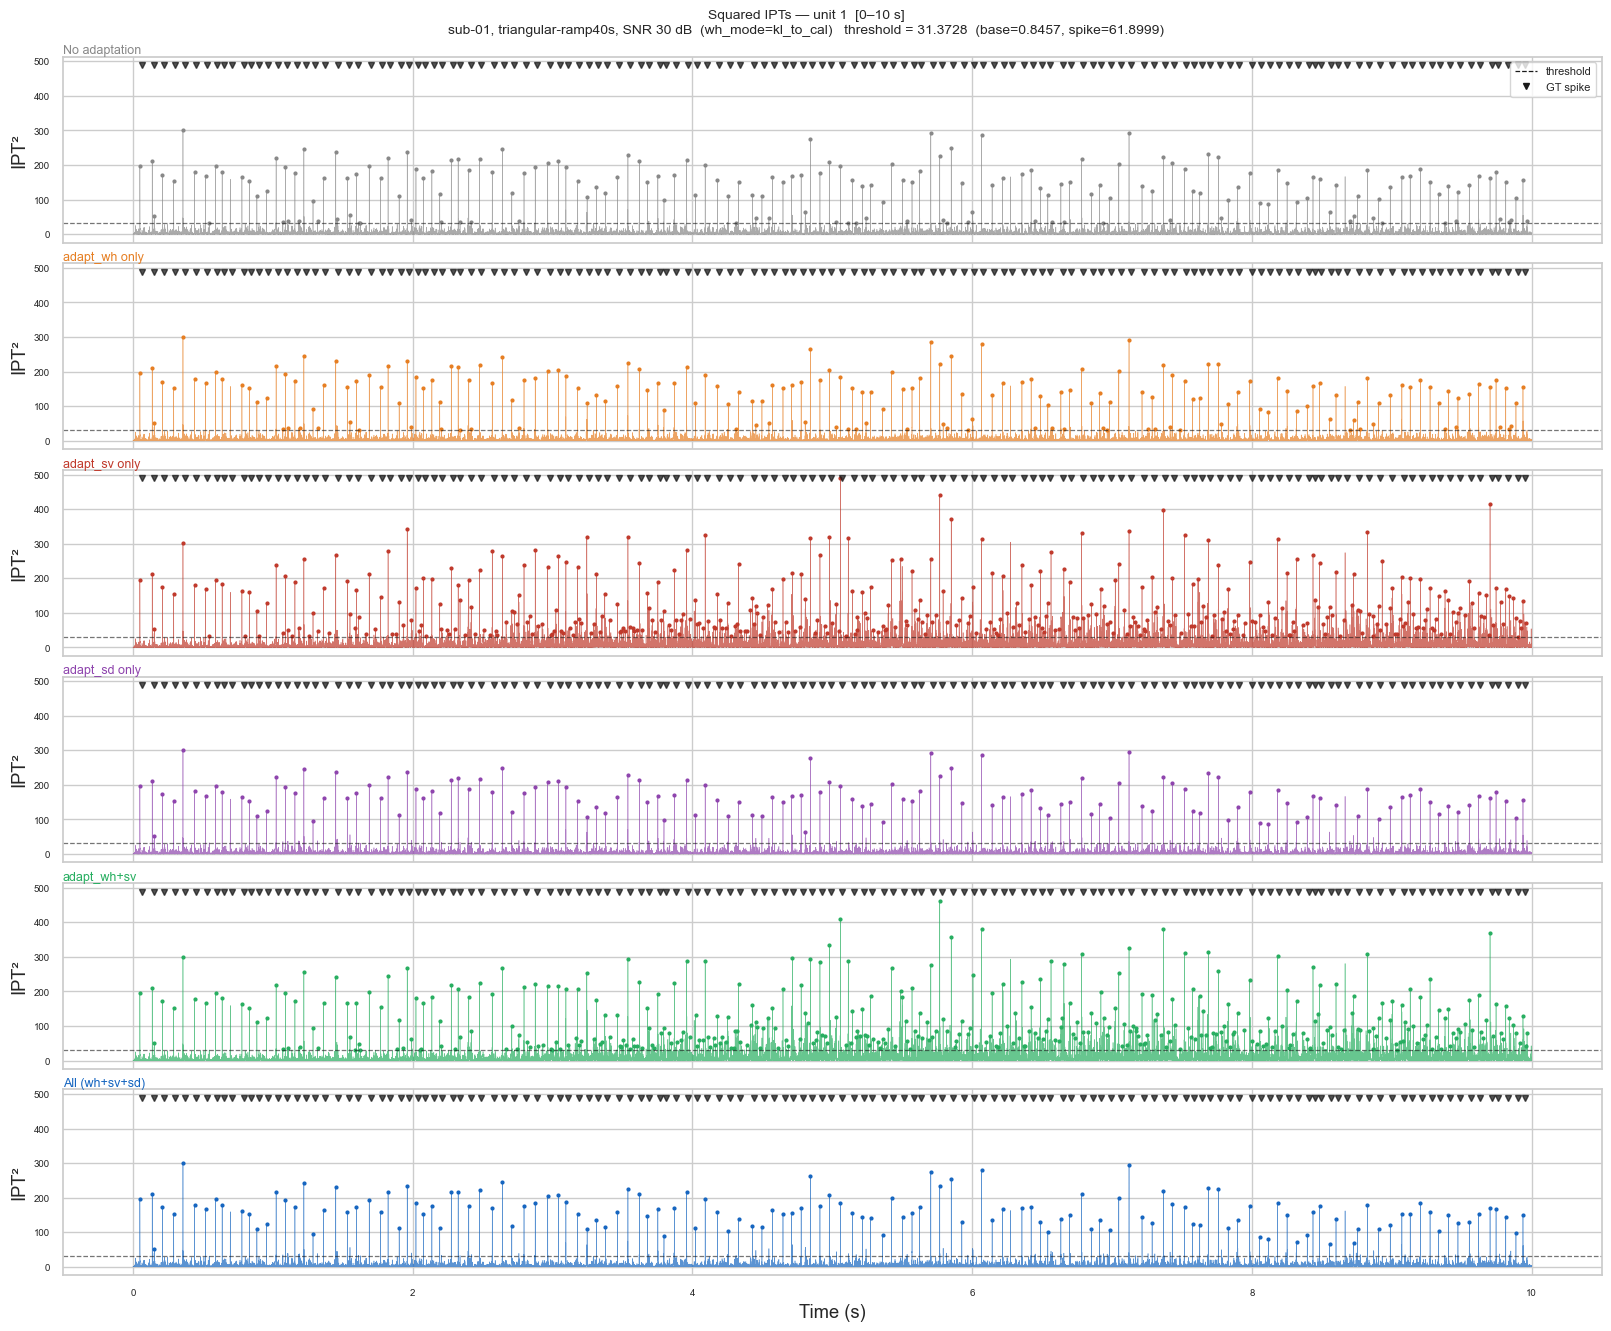

In [29]:
# ── Selection flags ───────────────────────────────────────────────────────────
ABL_MU_IDX = 0   # motor unit index
ABL_T0     = 0   # window start (seconds)
ABL_T1     = 10  # window end   (seconds) — set to _n / FS for the full recording

# ── Derived quantities ────────────────────────────────────────────────────────
idxs   = np.arange(int(ABL_T0 * FS), min(int(ABL_T1 * FS), _n))
t_axis = idxs / FS
u      = ABL_MU_IDX

base_c  = float(_data['base_centroids'][u])
spike_c = float(_data['spike_centroids'][u])
thresh  = base_c + (spike_c - base_c) / 2.0   # midpoint between centroids

# Max ipt² in the window across all conditions (y position for GT triangles)
max_h = max(float((d['ipts'][idxs, u] ** 2).max()) for d in abl.values())

# GT spike samples inside the window
gt_samp = np.where(_gt_bin[:, u].astype(bool))[0]
gt_samp = gt_samp[(gt_samp >= idxs[0]) & (gt_samp <= idxs[-1])]
gt_t    = gt_samp / FS

# ── Figure ────────────────────────────────────────────────────────────────────
n_rows = len(abl)
fig, axs = plt.subplots(n_rows, 1, figsize=(16, 2.2 * n_rows),
                        layout='constrained', sharex=True, sharey=True)
if n_rows == 1:
    axs = [axs]

for ax, (label, d) in zip(axs, abl.items()):
    ipts_sq = d['ipts'][idxs, u] ** 2
    smask   = d['spk'][idxs, u].astype(bool)

    ax.plot(t_axis, ipts_sq, color=ABL_COLORS[label], linewidth=0.4, alpha=0.7)
    ax.plot(t_axis[smask], ipts_sq[smask],
            linestyle='None', marker='.', markersize=4, color=ABL_COLORS[label])

    if len(gt_t):
        ax.plot(gt_t, np.full_like(gt_t, max_h),
                'v', color='k', markersize=5, alpha=0.75)

    ax.axhline(thresh, color='k', linewidth=0.9, linestyle='--', alpha=0.6)

    ax.set_title(label, loc='left', fontsize=9, color=ABL_COLORS[label], pad=2)
    ax.set(ylabel='IPT²')
    ax.tick_params(labelsize=7)

axs[-1].set(xlabel='Time (s)')

import matplotlib.lines as mlines
axs[0].legend(
    handles=[
        mlines.Line2D([], [], color='k', linewidth=0.9, linestyle='--', label='threshold'),
        mlines.Line2D([], [], color='k', marker='v', markersize=5, linestyle='None', label='GT spike'),
    ],
    fontsize=8, loc='upper right',
)

plt.suptitle(
    f'Squared IPTs — unit {u + 1}  [{ABL_T0}–{ABL_T1} s]\n'
    f'{ABL_SUB}, {ABL_COND}, SNR {ABL_SNR} dB  (wh_mode={WH_MODE})'
    f'   threshold = {thresh:.4f}  (base={base_c:.4f}, spike={spike_c:.4f})',
    fontsize=10,
)
plt.show()

## 4. Overall RoA — all conditions and SNR levels

In [10]:
rows = []
for (sub, cond, snr), res in results.items():
    roa,    _, _ = rate_of_agreement_paired(
        res['gt_bin'], res['spikes'],       fs=FS, tol_spike_ms=2)
    roa_no, _, _ = rate_of_agreement_paired(
        res['gt_bin'], res['spikes_noopt'], fs=FS, tol_spike_ms=2)
    for u, (r, r0) in enumerate(zip(roa, roa_no)):
        rows.append({'sub': sub, 'condition': cond, 'snr': snr, 'unit': u,
                     'roa': float(r), 'roa_noopt': float(r0)})

df = pd.DataFrame(rows)
df['roa_pct']       = df['roa']       * 100
df['roa_noopt_pct'] = df['roa_noopt'] * 100

tbl = df.groupby(['condition', 'snr'])[['roa_pct', 'roa_noopt_pct']].mean().round(2)
tbl.columns = ['Adapted (%)', 'No-adapt (%)']
tbl['Delta (pp)'] = (tbl['Adapted (%)'] - tbl['No-adapt (%)']).round(2)

print('Mean RoA — adapted vs no-adaptation (averaged across subjects and units):')
print(tbl.to_string())

Mean RoA — adapted vs no-adaptation (averaged across subjects and units):
                        Adapted (%)  No-adapt (%)  Delta (pp)
condition          snr                                       
staircase          15         38.34         50.10      -11.76
                   20         36.55         51.01      -14.46
                   25         34.59         45.79      -11.20
                   30         31.92         42.18      -10.26
triangular-ramp10s 15         40.27         54.21      -13.94
                   20         33.77         52.77      -19.00
                   25         31.30         48.12      -16.82
                   30         29.90         44.92      -15.02
triangular-ramp20s 15         44.68         58.41      -13.73
                   20         38.49         53.43      -14.94
                   25         35.07         45.86      -10.79
                   30         36.38         43.74       -7.36
triangular-ramp40s 15         37.77         53.60      -15

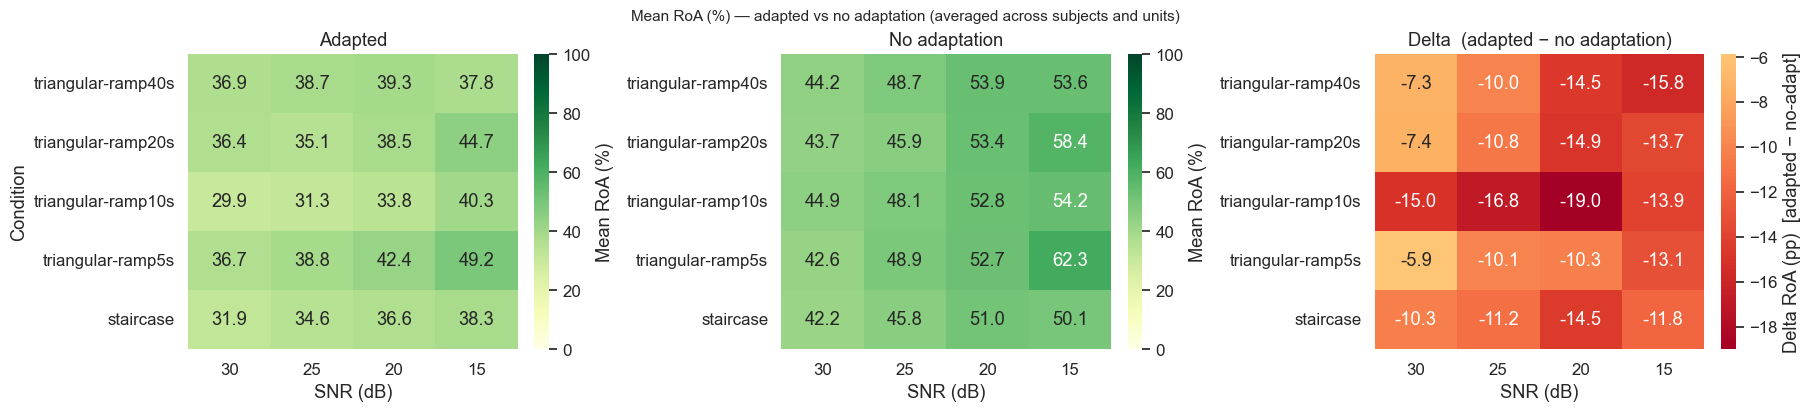

In [11]:
pivot_ad  = (df.groupby(['condition', 'snr'])['roa_pct'].mean()
             .unstack('snr').reindex(index=CONDITIONS, columns=SNR_LEVELS))
pivot_no  = (df.groupby(['condition', 'snr'])['roa_noopt_pct'].mean()
             .unstack('snr').reindex(index=CONDITIONS, columns=SNR_LEVELS))
pivot_del = pivot_ad - pivot_no

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4), layout='constrained')

common = dict(annot=True, fmt='.1f', cmap='YlGn', vmin=0, vmax=100,
              cbar_kws={'label': 'Mean RoA (%)'})
sns.heatmap(pivot_ad, ax=ax1, **common)
ax1.set(title='Adapted', xlabel='SNR (dB)', ylabel='Condition')

sns.heatmap(pivot_no, ax=ax2, **common)
ax2.set(title='No adaptation', xlabel='SNR (dB)', ylabel='')

# Delta: positive = adaptation helps, negative = adaptation hurts
sns.heatmap(pivot_del, ax=ax3, annot=True, fmt='.1f',
            cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Delta RoA (pp)  [adapted − no-adapt]'})
ax3.set(title='Delta  (adapted − no adaptation)', xlabel='SNR (dB)', ylabel='')

plt.suptitle(
    'Mean RoA (%) — adapted vs no adaptation (averaged across subjects and units)',
    fontsize=11,
)
plt.show()

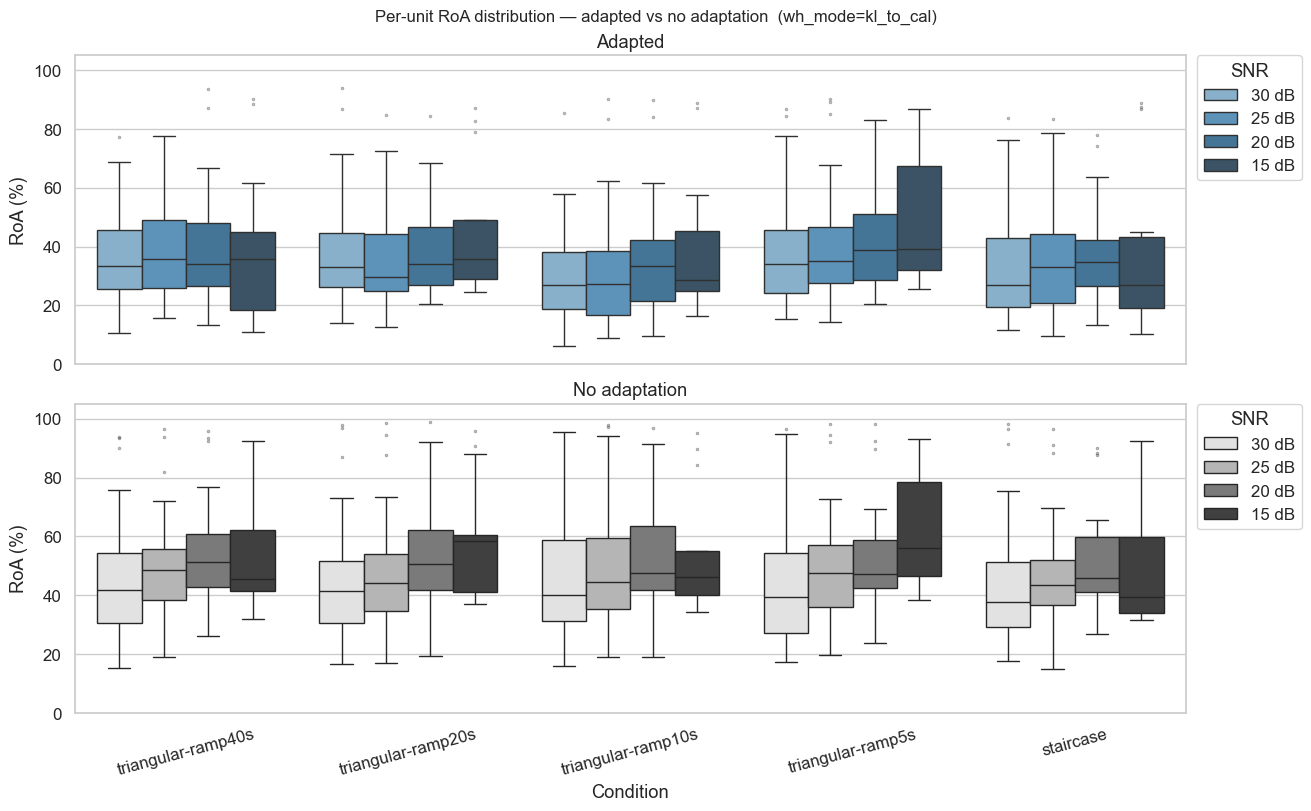

In [12]:
df['SNR'] = df['snr'].astype(str) + ' dB'
snr_order = [f'{s} dB' for s in SNR_LEVELS]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 8), layout='constrained',
                                      sharex=True, sharey=True)

sns.boxplot(
    data=df, x='condition', y='roa_pct', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d', flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=ax_top,
)
ax_top.set(ylabel='RoA (%)', xlabel='', title='Adapted', ylim=(0, 105))
ax_top.legend(title='SNR', bbox_to_anchor=(1.01, 1), borderaxespad=0)

sns.boxplot(
    data=df, x='condition', y='roa_noopt_pct', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Greys', flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=ax_bot,
)
ax_bot.set(ylabel='RoA (%)', xlabel='Condition', title='No adaptation', ylim=(0, 105))
ax_bot.tick_params(axis='x', rotation=15)
ax_bot.legend(title='SNR', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.suptitle(
    f'Per-unit RoA distribution — adapted vs no adaptation  (wh_mode={WH_MODE})',
    fontsize=12,
)
plt.show()

## 5. Phase RoA for triangular contractions

Three phases are identified from the wrist angle signal using a
`ANGLE_ISO_THR_DEG = 2°` threshold:
1. **First isometric** — flat segment at the start of the adaptation window
2. **Triangular ramp** — angle actively changing
3. **Last isometric** — flat segment at the end

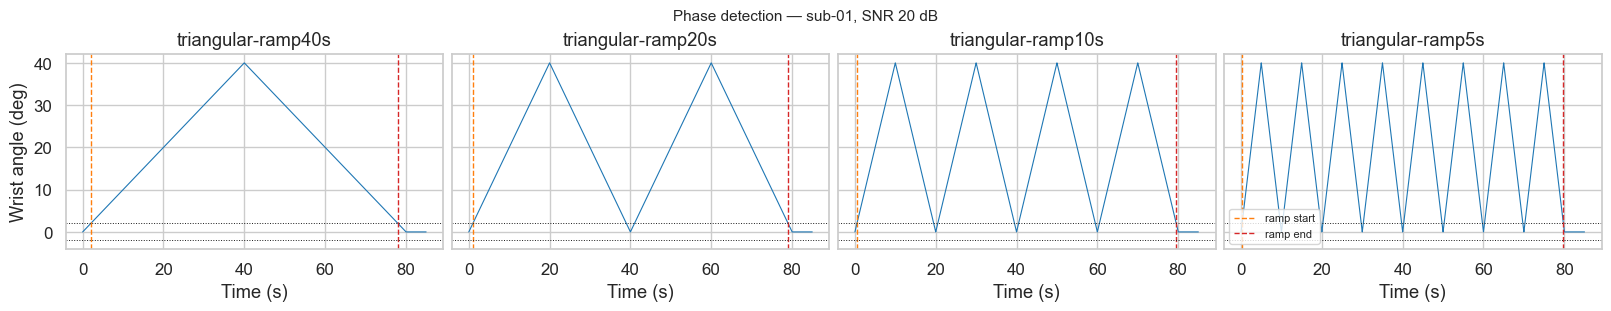

In [13]:
# Sanity check: plot angle profiles and detected phase boundaries for one subject
sub_check = 'sub-01'
snr_check = 20
n_tri     = len(TRIANGULAR)

fig, axs = plt.subplots(1, n_tri, figsize=(4 * n_tri, 3), layout='constrained', sharey=True)
for ax, cond in zip(axs, TRIANGULAR):
    key    = (sub_check, cond, snr_check)
    angle  = results[key]['angle_adapt']
    t      = np.arange(len(angle)) / FS
    phases = detect_triangular_phases(angle)
    ax.plot(t, angle, color='tab:blue', linewidth=0.8)
    ax.axvline(phases['ramp_start'] / FS, color='tab:orange', linestyle='--',
               linewidth=1, label='ramp start')
    ax.axvline(phases['ramp_end'] / FS, color='tab:red', linestyle='--',
               linewidth=1, label='ramp end')
    ax.axhline(ANGLE_ISO_THR_DEG,  color='k', linestyle=':', linewidth=0.7)
    ax.axhline(-ANGLE_ISO_THR_DEG, color='k', linestyle=':', linewidth=0.7)
    ax.set(title=cond, xlabel='Time (s)')
axs[0].set_ylabel('Wrist angle (deg)')
axs[-1].legend(fontsize=8)
plt.suptitle(f'Phase detection — {sub_check}, SNR {snr_check} dB', fontsize=11)
plt.show()

In [14]:
PHASE_ORDER  = ['first_iso', 'ramp', 'last_iso']
PHASE_LABELS = {
    'first_iso': 'First isometric',
    'ramp':      'Triangular ramp',
    'last_iso':  'Last isometric',
}

phase_rows = []
for (sub, cond, snr), res in results.items():
    if cond not in TRIANGULAR:
        continue
    phases = detect_triangular_phases(res['angle_adapt'])
    for phase_name in PHASE_ORDER:
        idx    = phases[phase_name]
        roa    = compute_roa_subset(res['gt_bin'], res['spikes'],       idx)
        roa_no = compute_roa_subset(res['gt_bin'], res['spikes_noopt'], idx)
        for u, (r, r0) in enumerate(zip(roa, roa_no)):
            phase_rows.append({
                'sub':       sub,
                'condition': cond,
                'snr':       snr,
                'phase':     phase_name,
                'unit':      u,
                'roa':       float(r),
                'roa_noopt': float(r0),
            })

df_phase = pd.DataFrame(phase_rows)
df_phase['roa_pct']       = df_phase['roa']       * 100
df_phase['roa_noopt_pct'] = df_phase['roa_noopt'] * 100
df_phase['phase'] = pd.Categorical(df_phase['phase'],
                                    categories=PHASE_ORDER, ordered=True)
print(f'Phase-RoA rows: {len(df_phase)}')

Phase-RoA rows: 1734


In [15]:
for cond in TRIANGULAR:
    df_c = df_phase[df_phase['condition'] == cond]

    # Adapted
    tbl_ad = (
        df_c.groupby(['snr', 'phase'], observed=True)['roa_pct']
        .agg(['mean', 'std']).round(2).unstack('phase')
    )
    tbl_ad.columns = [f'{m} ({p})' for m, p in tbl_ad.columns]
    col_order = [f'{m} ({p})' for p in PHASE_ORDER for m in ['mean', 'std']]
    tbl_ad = tbl_ad[[c for c in col_order if c in tbl_ad.columns]]

    # No-adapt (mean only)
    tbl_no = (
        df_c.groupby(['snr', 'phase'], observed=True)['roa_noopt_pct']
        .mean().round(2).unstack('phase')
    )
    tbl_no.columns = [f'no-adapt ({p})' for p in tbl_no.columns]
    tbl_no = tbl_no[[c for c in [f'no-adapt ({p})' for p in PHASE_ORDER]
                     if c in tbl_no.columns]]

    # Delta (adapted mean − no-adapt mean)
    tbl_del = pd.DataFrame(
        {f'delta ({p})': tbl_ad[f'mean ({p})'] - tbl_no[f'no-adapt ({p})']
         for p in PHASE_ORDER},
    ).round(2)

    print(f'\n=== {cond} ===')
    print(tbl_ad.to_string())
    print('\nNo-adapt mean & delta (adapted − no-adapt):')
    print(pd.concat([tbl_no, tbl_del], axis=1).to_string())
    print()


=== triangular-ramp40s ===
     mean (first_iso)  std (first_iso)  mean (ramp)  std (ramp)  mean (last_iso)  std (last_iso)
snr                                                                                             
15              90.98            11.00        35.36       23.46            62.03           30.82
20              93.02             8.66        36.43       19.84            71.38           30.12
25              92.57             7.32        35.21       16.16            78.18           24.96
30              89.68            12.06        33.23       15.27            80.92           24.28

No-adapt mean & delta (adapted − no-adapt):
     no-adapt (first_iso)  no-adapt (ramp)  no-adapt (last_iso)  delta (first_iso)  delta (ramp)  delta (last_iso)
snr                                                                                                               
15                  82.47            50.22                83.81               8.51        -14.86            -21.78


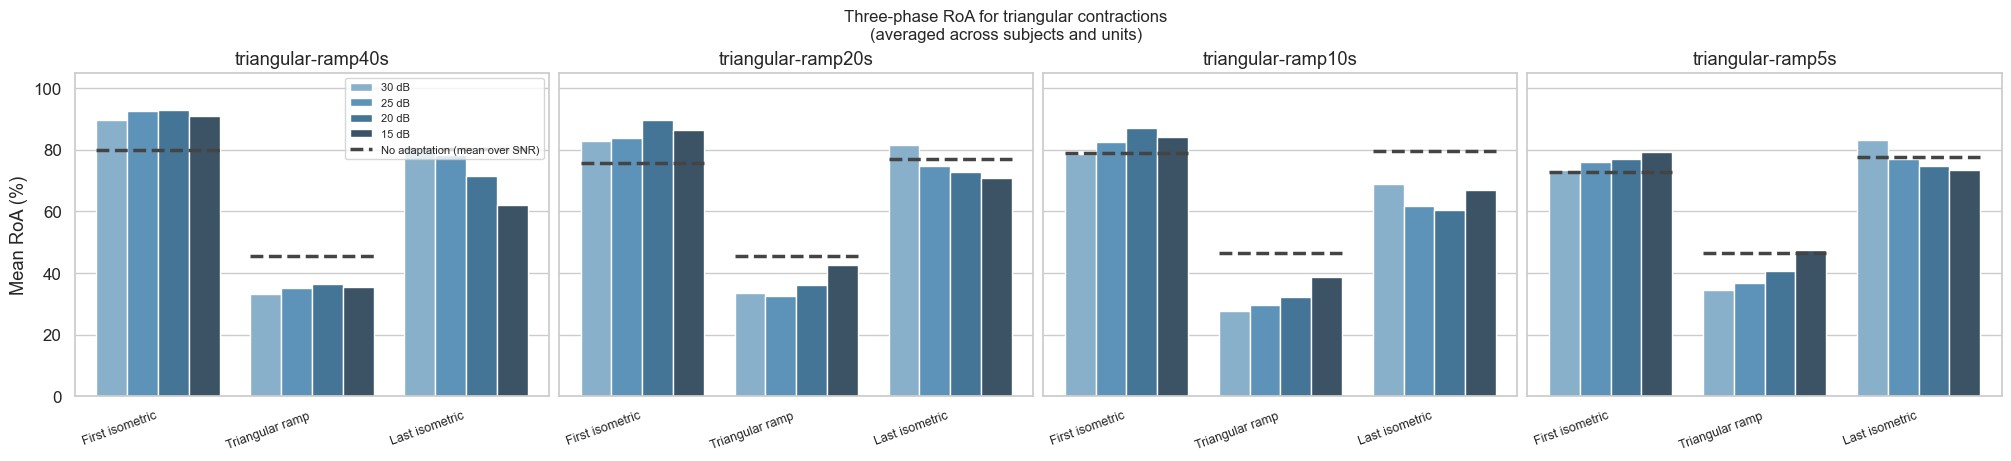

In [16]:
import matplotlib.lines as mlines

fig, axs = plt.subplots(1, n_tri, figsize=(5 * n_tri, 4.5),
                         layout='constrained', sharey=True)

for ax_idx, (ax, cond) in enumerate(zip(axs, TRIANGULAR)):
    df_c = df_phase[df_phase['condition'] == cond]

    mean_df = (
        df_c.groupby(['snr', 'phase'], observed=True)['roa_pct']
        .mean().reset_index()
    )
    mean_df['SNR'] = mean_df['snr'].astype(str) + ' dB'
    sns.barplot(
        data=mean_df, x='phase', y='roa_pct', hue='SNR',
        hue_order=snr_order, order=PHASE_ORDER,
        palette='Blues_d', ax=ax,
    )

    # Grey dashed line per phase: no-adapt mean (averaged over all SNR & subjects)
    noopt_mean = df_c.groupby('phase', observed=True)['roa_noopt_pct'].mean()
    for xi, phase in enumerate(PHASE_ORDER):
        y = noopt_mean.get(phase, np.nan)
        if not np.isnan(y):
            ax.plot([xi - 0.4, xi + 0.4], [y, y],
                    color='#444', linewidth=2.5, linestyle='--')

    ax.set(xlabel='', ylabel='Mean RoA (%)', title=cond, ylim=(0, 105))
    ax.set_xticks(range(len(PHASE_ORDER)))
    ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                       rotation=20, ha='right', fontsize=9)
    if ax_idx != 0:
        ax.set_ylabel('')
        ax.get_legend().remove()

# Augment first subplot's legend with no-adapt indicator
handles_l, labels_l = axs[0].get_legend_handles_labels()
no_h = mlines.Line2D([], [], color='#444', linewidth=2.5, linestyle='--',
                     label='No adaptation (mean over SNR)')
axs[0].legend(handles=handles_l + [no_h], labels=labels_l + ['No adaptation (mean over SNR)'],
              fontsize=8, loc='upper right')
axs[0].set_ylabel('Mean RoA (%)')

plt.suptitle(
    'Three-phase RoA for triangular contractions\n'
    '(averaged across subjects and units)',
    fontsize=12,
)
plt.show()

## 6. Summary figure

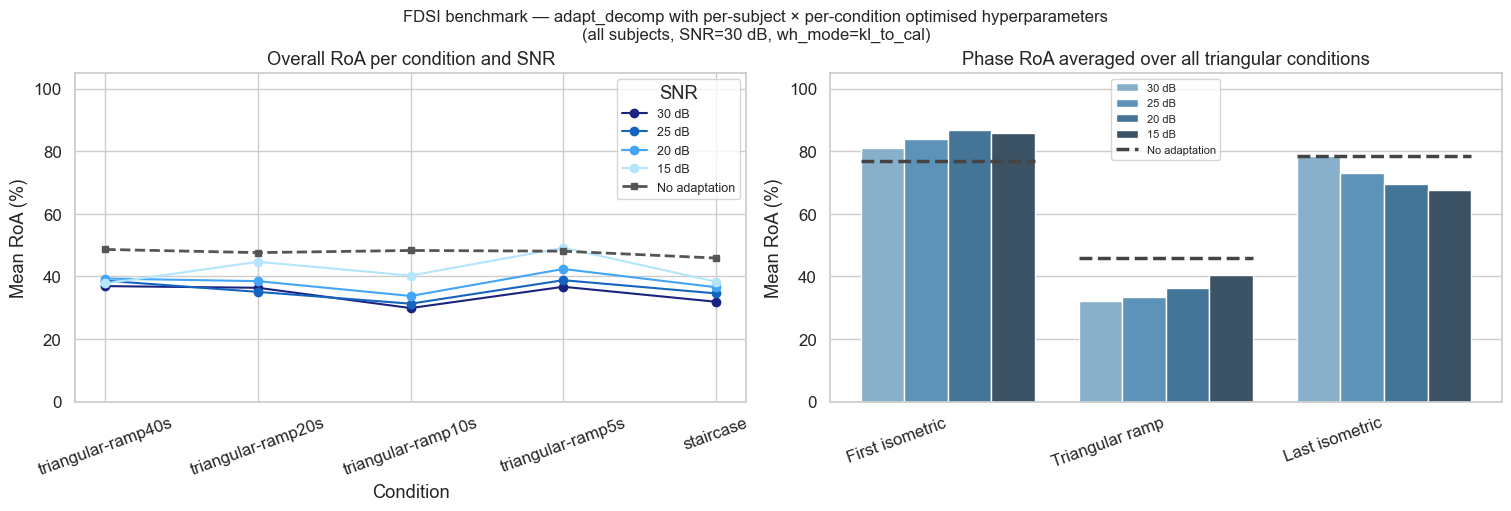

In [17]:
import matplotlib.lines as mlines

colors_snr = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

fig, axs = plt.subplots(1, 2, figsize=(15, 5), layout='constrained')

# ── Left: overall mean RoA per condition, one colored line per SNR ────────────
mean_by      = df.groupby(['condition', 'snr'])['roa_pct'].mean().reset_index()
noopt_by_cond = df.groupby('condition')['roa_noopt_pct'].mean().reindex(CONDITIONS)

for snr in SNR_LEVELS:
    sub_df = mean_by[mean_by['snr'] == snr].set_index('condition').reindex(CONDITIONS)
    axs[0].plot(
        CONDITIONS, sub_df['roa_pct'],
        marker='o', label=f'{snr} dB', color=colors_snr[snr],
    )

no_line, = axs[0].plot(
    CONDITIONS, noopt_by_cond,
    color='#555', linewidth=2, linestyle='--', marker='s', markersize=5,
    label='No adaptation',
)

axs[0].set(
    ylabel='Mean RoA (%)',
    title='Overall RoA per condition and SNR',
    ylim=(0, 105),
    xlabel='Condition',
)
axs[0].tick_params(axis='x', rotation=20)
axs[0].legend(title='SNR', fontsize=9)

# ── Right: three-phase RoA averaged over all triangular conditions ─────────────
phase_mean = (
    df_phase.groupby(['snr', 'phase'], observed=True)['roa_pct']
    .mean().reset_index()
)
phase_mean['SNR'] = phase_mean['snr'].astype(str) + ' dB'
sns.barplot(
    data=phase_mean, x='phase', y='roa_pct', hue='SNR',
    hue_order=snr_order, order=PHASE_ORDER,
    palette='Blues_d', ax=axs[1],
)

# Grey dashed lines: no-adapt phase mean (all conditions × SNR × subjects)
noopt_phase = df_phase.groupby('phase', observed=True)['roa_noopt_pct'].mean()
for xi, phase in enumerate(PHASE_ORDER):
    y = noopt_phase.get(phase, np.nan)
    if not np.isnan(y):
        axs[1].plot([xi - 0.4, xi + 0.4], [y, y],
                    color='#444', linewidth=2.5, linestyle='--')

axs[1].set_xticks(range(len(PHASE_ORDER)))
axs[1].set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                        rotation=20, ha='right')
axs[1].set(
    ylabel='Mean RoA (%)',
    title='Phase RoA averaged over all triangular conditions',
    ylim=(0, 105),
    xlabel='',
)
handles_r, labels_r = axs[1].get_legend_handles_labels()
no_h = mlines.Line2D([], [], color='#444', linewidth=2.5, linestyle='--',
                     label='No adaptation')
axs[1].legend(handles=handles_r + [no_h], labels=labels_r + ['No adaptation'],
              fontsize=8)

plt.suptitle(
    f'FDSI benchmark — adapt_decomp with per-subject × per-condition optimised hyperparameters'
    f'\n(all subjects, SNR={OPT_SNR} dB, wh_mode={WH_MODE})',
    fontsize=12,
)
plt.show()